# Evaluation Harness: Project Scoreboard and Model Comparison

This notebook is the project scoreboard. It loads every experiment's metrics from `results/metrics/`, builds the results ladder that ranks all models, and runs the cross-experiment comparisons (per-class recall heatmap, suicidal-recall tracking, paired significance tests) for Parts 1 to 4. It is the single place every part is scored and compared. Run it top to bottom after any new experiment; it reads only validated metrics and excludes any scored on a drifted test set.

## Table of Contents
1. [Evaluation Methodology](#1.-Evaluation-Methodology)
2. [Setup & Environment](#2.-Setup-&-Environment)
    * [Standard Scoring Ritual](#Standard-Scoring-Ritual)
3. [Baseline Initialization (SOA & Random)](#3.-Baseline-Initialization-(SOA-&-Random))
    * [3.1 State-of-the-Art (SOA) Reference](#State-of-the-Art-(SOA)-Reference)
    * [3.2 Random Baseline](#Random-Baseline)
4. [Detailed Diagnostics & Error Analysis](#4.-Detailed-Diagnostics-&-Error-Analysis)
    * [4.1 Visual Confusion Matrix](#4.1-Visual-Confusion-Matrix)
    * [4.2 Per-Class Recall Heatmap](#4.2-Per-Class-Recall-Heatmap)
    * [4.3 Suicidal Recall (Ethics-Critical Metric)](#4.3-Suicidal-Recall-(Ethics-Critical-Metric))
    * [4.4 Suicidal False Negatives](#4.4-Suicidal-False-Negatives)
5. [Overall Results Ladder](#5.-Overall-Results-Ladder)
    * [5.1 Macro F1 vs Suicidal Recall](#5.1-Macro-F1-vs-Suicidal-Recall)
    * [5.2 Top 3 Models vs. SOA](#5.2-Top-3-Models-vs.-SOA)
6. [Statistical Significance (Paired Tests)](#6.-Statistical-Significance-(Paired-Tests))

## 1. Evaluation Methodology

All experiments strictly follow the same rules:

* **Fixed Test Set:** A single immutable test file (`data/processed/test.parquet`), verified by a guard cell.
* **Strict Data Usage:** Models are tuned only on validation data and evaluated once on the frozen test set.
* **Standard Metrics:** Track accuracy, F1, kappa, and per-class metrics (`src/utils/metrics.py`). **Suicidal recall** is prioritized due to ethical criticality.
* **Consistent Tracking:** Results (JSONs) and predictions (CSVs) are saved with dataset fingerprints for later statistical testing.
* **Automation:** `evaluate_model()` automates scoring for Parts 2 to 4.

## 2. Setup & Environment
Environment Setup & Data Loading: System paths, dependencies, and split guard.


In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    !pip install -q datasets==4.8.5
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print('Local run detected - no Colab setup needed.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import itertools
import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.metrics import precision_recall_fscore_support

In [5]:
# Setup: project root + sys.path.insert make src/ importable; bootstrap() then handles
# config load, seeding, and the standard results paths (src/utils/notebook_setup.py).
def _find_project_root(start):
    candidates = [start, *start.parents,
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT/Final_submission'),
                  Path('/content/drive/MyDrive/BSE/NLP-PROJECT')]
    for d in candidates:
        if (d / 'data' / 'processed').exists():
            return d
    raise FileNotFoundError(
        )


PROJECT_ROOT = _find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(PROJECT_ROOT))
from src.utils.notebook_setup import bootstrap
from src.utils.metrics import load_predictions, mcnemar_test
from src.utils.visualization import (
    plot_dataset_overview, plot_text_length_distributions, plot_baseline_comparison,
    plot_random_baseline, plot_rulebased_confusion, plot_confusion_from_predictions,
    plot_results_ladder, plot_f1_vs_recall,
    plot_top3_vs_soa, plot_recall_heatmap, plot_suicidal_recall,
)


S = bootstrap(PROJECT_ROOT)
_CFG = S.cfg
SEED = S.SEED                                   # random + numpy already seeded inside bootstrap()
DATA_DIR, RESULTS_DIR, METRICS_DIR, PRED_DIR, FIG_DIR = (
    S.DATA_DIR, S.RESULTS_DIR, S.METRICS_DIR, S.PRED_DIR, S.FIG_DIR)
N_BOOT = _CFG['eval']['n_boot']
save_fig = S.save_fig

sns.set_theme(style="whitegrid", font_scale=1.1)

MODEL_NAMES = yaml.safe_load((PROJECT_ROOT / 'config' / 'display_names.yaml').read_text())['model_names']

def format_model_name(name, n=None, full_n=None):
    base = MODEL_NAMES.get(name, name.replace('_', ' ').title())
    return f"{base} (N={n})" if n and full_n and n != full_n else base

In [8]:
from src.utils.evaluation import make_evaluate_model, load_all_metrics as _load_all_metrics
from src.utils.guards import run_split_guard

guard = run_split_guard(DATA_DIR, expected_revision=_CFG['dataset']['revision'])
labels, classes, splits = guard['labels'], guard['classes'], guard['splits']
test_df, y_test, manifest = guard['test_df'], guard['y_test'], guard['manifest']


Split guard OK - test fingerprint 0da3f09e8a2b... matches the manifest.
Frozen splits: 64,069 train / 16,018 val / 20,022 test  -  dataset revision 186902250e94...


In [9]:
def load_all_metrics():
    """Load metrics scored on the frozen test set (see src.utils.evaluation)."""
    return _load_all_metrics(METRICS_DIR, manifest['test_ids_sha256'])


### Standard Scoring Ritual

A single call to `evaluate_model()` automates the workflow: it computes metrics and confidence intervals, saves results to `results/metrics/` (JSON) and `results/predictions/` (CSV), and generates standard reports including headline metrics, suicidal recall analysis, and row-normalized confusion matrices.

In [10]:
evaluate_model = make_evaluate_model(test_df=test_df, y_test=y_test, classes=classes,
                                     fig_dir=FIG_DIR, n_boot=N_BOOT, seed=SEED)

print('evaluate_model() ready - Parts 2-4 score their frozen models through this one call.')

evaluate_model() ready - Parts 2-4 score their frozen models through this one call.


In [16]:
def get_results_ladder():
    """Loads all metrics and builds the overall results ladder."""
    rows = [{
        'experiment': m['name'],
        'part': m['name'].split('_')[0],
        'n': m.get('n'),
        'accuracy': m.get('accuracy'),
        'acc_ci95_low':  (m.get('accuracy_ci95') or [None, None])[0],
        'acc_ci95_high': (m.get('accuracy_ci95') or [None, None])[1],
        'macro_f1': m.get('macro_f1'),
        'kappa': m.get('kappa'),
        'suicidal_recall': m.get('per_class', {}).get('suicidal', {}).get('recall'),
    } for m in load_all_metrics()]

    ladder_df = pd.DataFrame(rows).sort_values('accuracy').reset_index(drop=True)
    ladder_df.to_csv(METRICS_DIR / 'summary_all.csv', index=False)
    return ladder_df

# Generate the ladder
ladder = get_results_ladder()

# Formatting for display
shown = ladder.copy()
shown['experiment'] = shown.apply(lambda row: format_model_name(row['experiment'], row['n'], len(y_test)), axis=1)
for c in ('accuracy', 'acc_ci95_low', 'acc_ci95_high', 'macro_f1', 'kappa', 'suicidal_recall'):
    shown[c] = shown[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '-')

print(shown.to_string(index=False))
print(f"\nSaved results/metrics/summary_all.csv ({len(ladder)} experiments)")

                          experiment  part       n accuracy acc_ci95_low acc_ci95_high macro_f1  kappa suicidal_recall
                     Random Baseline part1 20022.0   0.1454            -             -   0.1429      -               -
                   Majority Baseline part1 20022.0   0.1667            -             -   0.0408 0.0000          0.0000
                   BERT (32 samples) part2 20022.0   0.5768       0.5699        0.5836   0.5500 0.5023          0.1630
                      BERT (1% Data) part3 20022.0   0.6118       0.6051        0.6181   0.5527 0.5426          0.0000
                      BERT (EDA 160) part2 20022.0   0.6363       0.6304        0.6432   0.6304 0.5734          0.2722
                   BERT (Synth Only) part2 20022.0   0.6432       0.6372        0.6498   0.6220 0.5824          0.2590
              Lexicon (Hand-crafted) part1 20022.0   0.6690       0.6627        0.6759   0.6701 0.6108          0.4135
              BERT (Backtranslation) part2 20022

## 3. Baseline Initialization (SOA & Random)

### State-of-the-Art (SOA) Reference
Initialize the dashboard with a State-of-the-Art (SOA) reference model to serve as a benchmark. Replace the default placeholder metrics with the exact figures from your chosen SOA literature.

In [11]:
# The SOA reference row's frozen-test fingerprint is stamped only so the row sorts onto the comparison ladder.
soa_metrics = {
    "name": "part0_soa_reference",
    "external_reference": True,
    "source": "Sevinc 2025 (LatentGLoss), Table I, BERT (Finetuned), 7-class",
    "accuracy": 0.9483,
    "note": ("Published literature benchmark, NOT scored on our test set; same 7-class task but "
             "a different (merged/augmented) corpus, so the comparison is benchmark-level. The "
             "paper reports no kappa and no per-class numbers, so those are intentionally absent."),
    "provenance": {
        "test_ids_sha256": manifest['test_ids_sha256']
    }
}

soa_filepath = METRICS_DIR / f"{soa_metrics['name']}.json"
with open(soa_filepath, 'w') as f:
    json.dump(soa_metrics, f, indent=2)

print(f"Saved SOA reference to {soa_filepath.name} - re-run the ladder cell to pick it up.")


Saved SOA reference to part0_soa_reference.json - re-run the ladder cell to pick it up.


### Random Baseline

The random baseline is the floor: a model that guesses by the class proportions rather than learning, so any useful model must beat it. We assign labels in proportion to their frequency and repeat the simulation 1,000 times to get a range. With seven roughly balanced classes, random accuracy sits near 1/7 (about 14%). We also report macro F1, which averages per-class F1 so the baseline cannot look good by guessing common classes.

             experiment  accuracy  macro_f1    kappa  suicidal_recall                            accuracy_ci95
  part1_random_baseline  0.145365  0.142912      NaN              NaN                                     None
part1_majority_baseline  0.166717  0.040827 0.000000         0.000000                                     None
       part1_rule_based  0.669014  0.670065 0.610797         0.413516 [0.6627185096393966, 0.6758578064129458]
 part1_rule_based_mined  0.745080  0.749456 0.701356         0.453214 [0.7389359204874638, 0.7510738187993208]


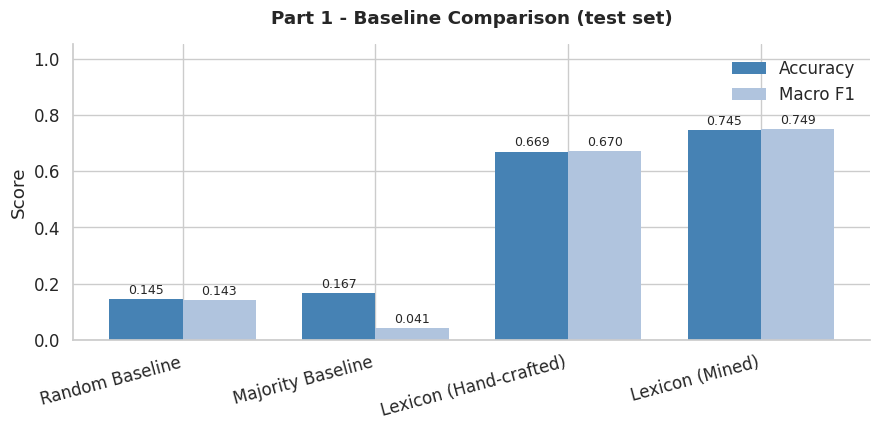

In [ ]:
plot_baseline_comparison(load_all_metrics, save_fig=save_fig, format_model_name=format_model_name)

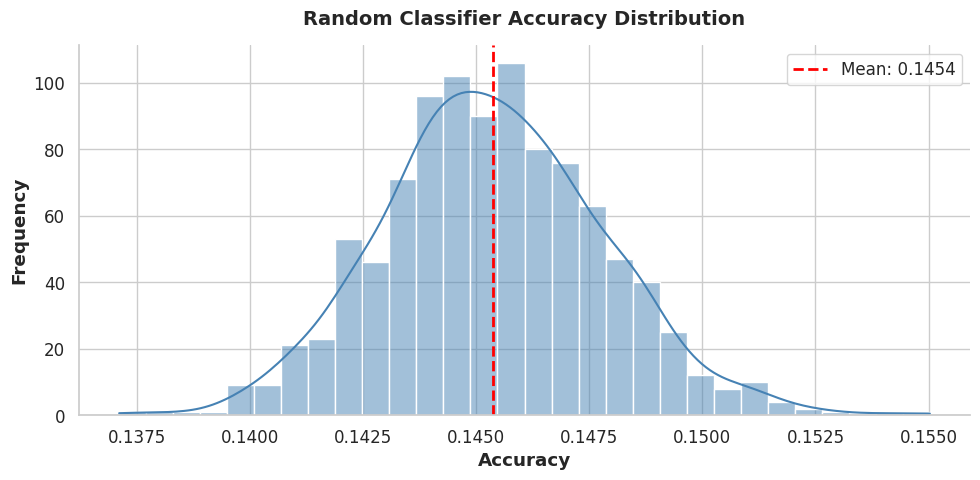

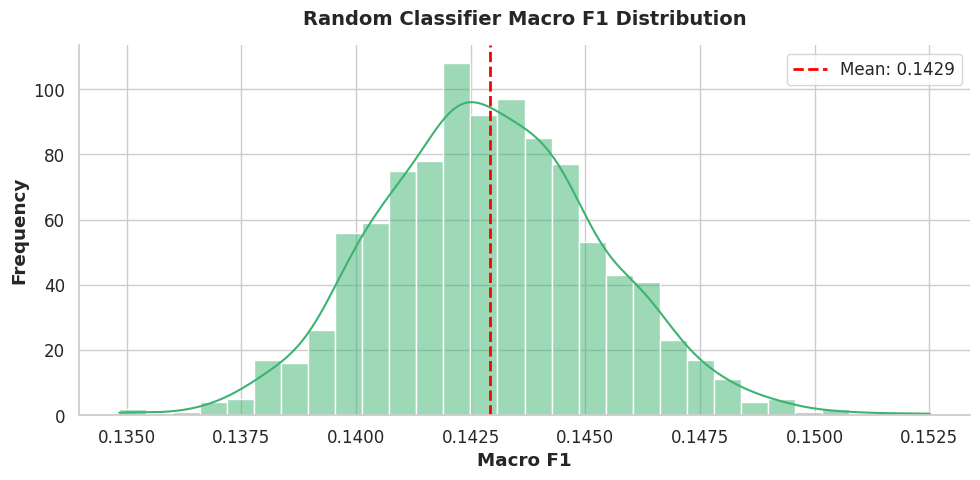

In [ ]:
# Dependencies: y_test, classes (from split guard); plot_random_baseline, save_fig, SEED, N_BOOT (from setup)
plot_random_baseline(y_test, classes, save_fig=save_fig, seed=SEED, n_boot=N_BOOT)

## 4. Detailed Diagnostics & Error Analysis



### 4.1 Visual Confusion Matrix

Visualizing the row-normalized confusion matrix makes it easy to see exactly where the model's predictions land. The diagonal represents correct predictions, while off-diagonal squares show the percentage of a true class being misclassified into another.

No saved predictions for part1_random_baseline - skipped.
No saved predictions for part1_majority_baseline - skipped.


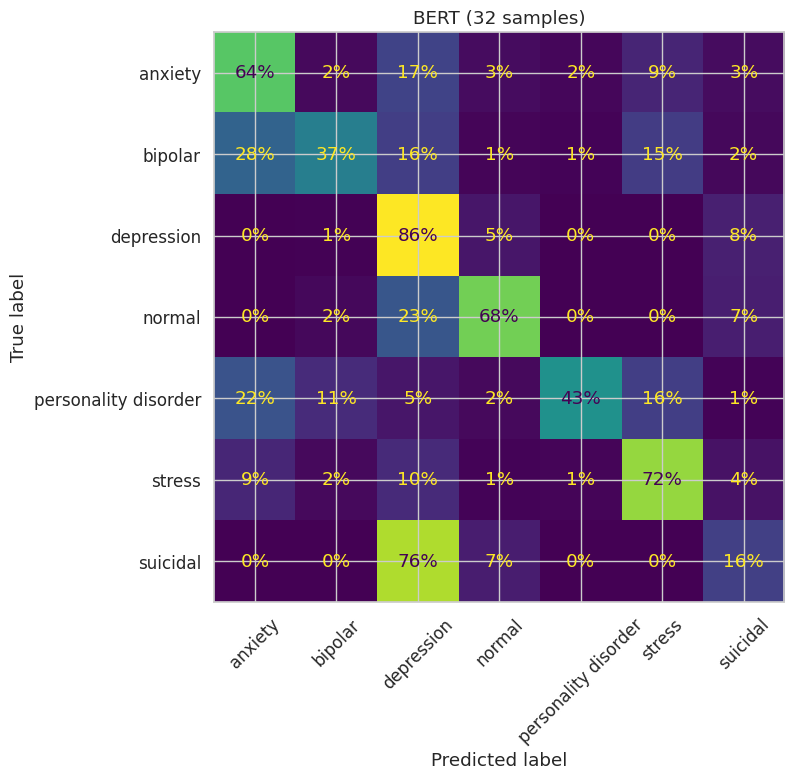

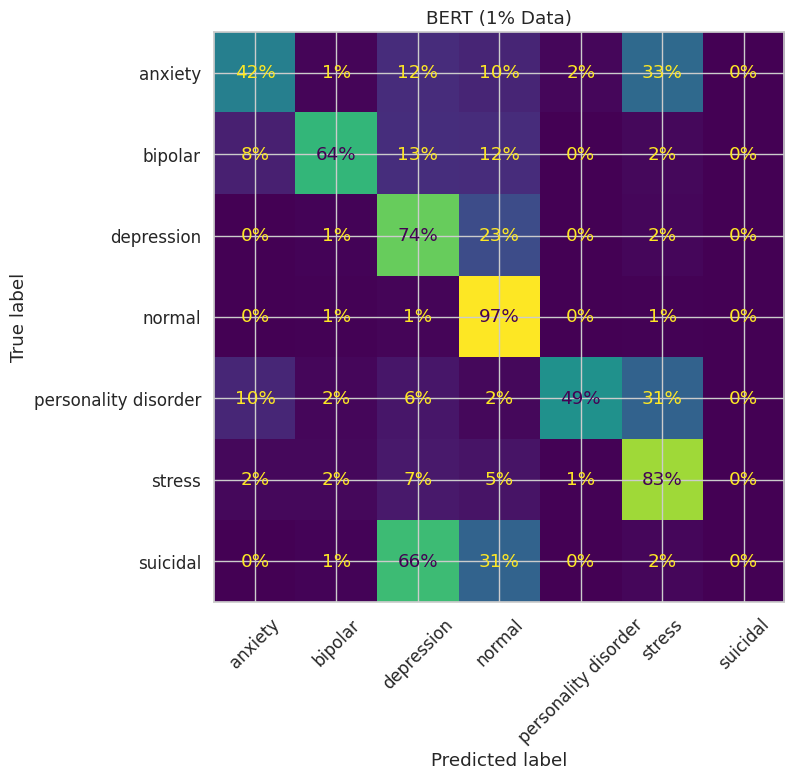

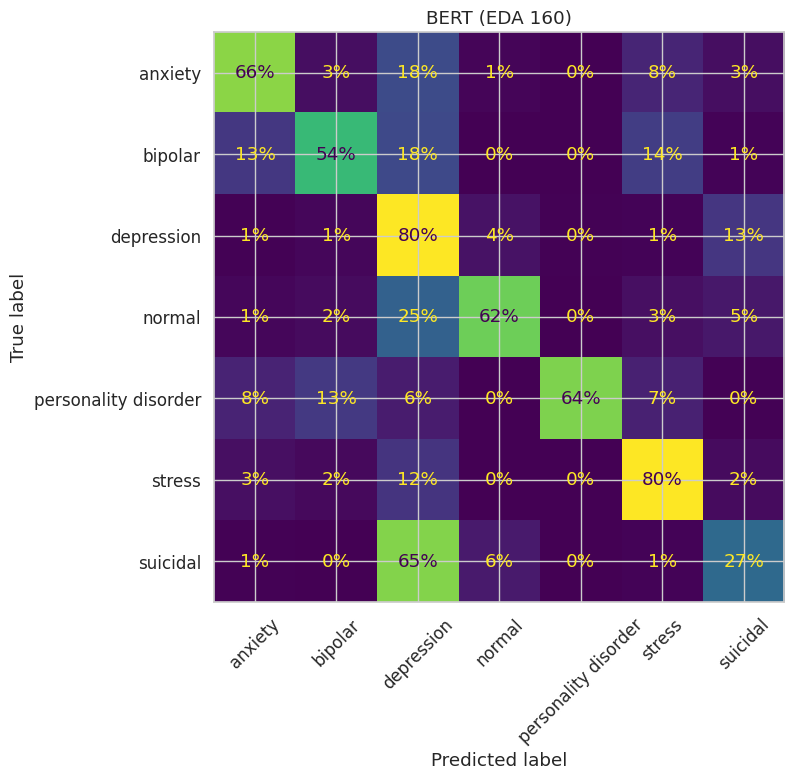

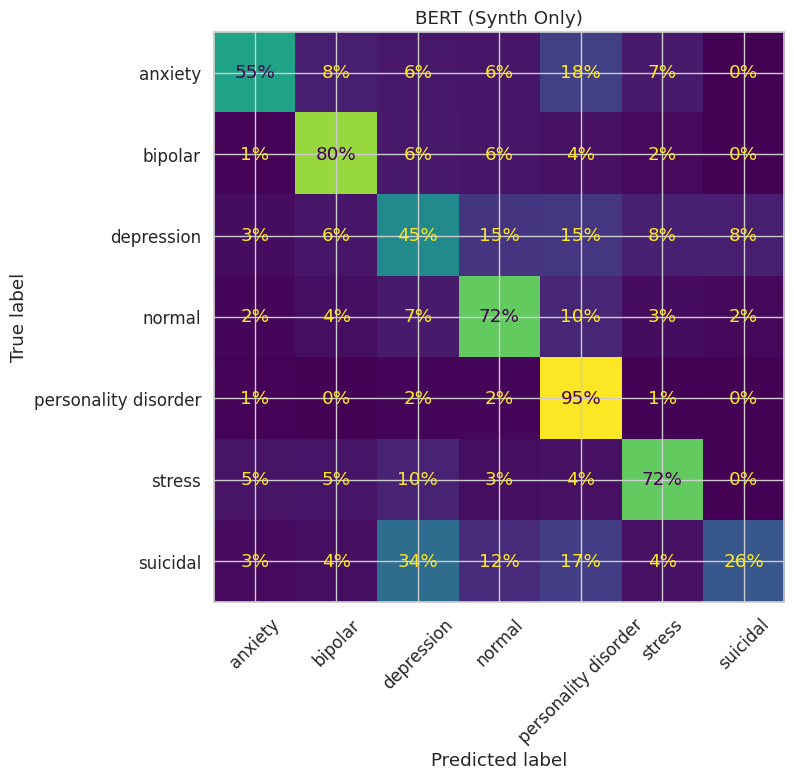

No saved predictions for part1_rule_based - skipped.


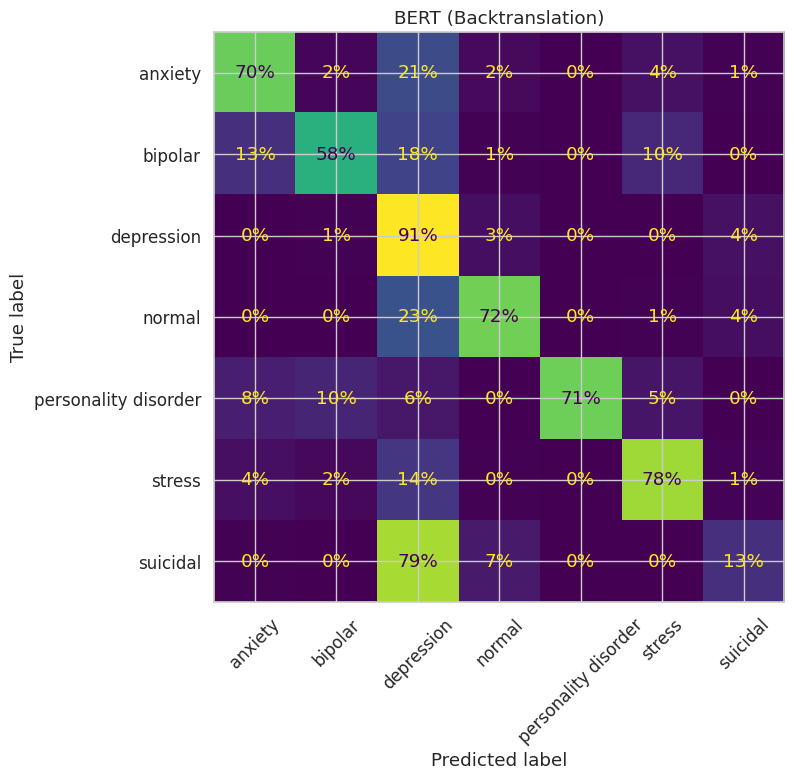

No saved predictions for part2_zero_shot_llm_n2100 - skipped.


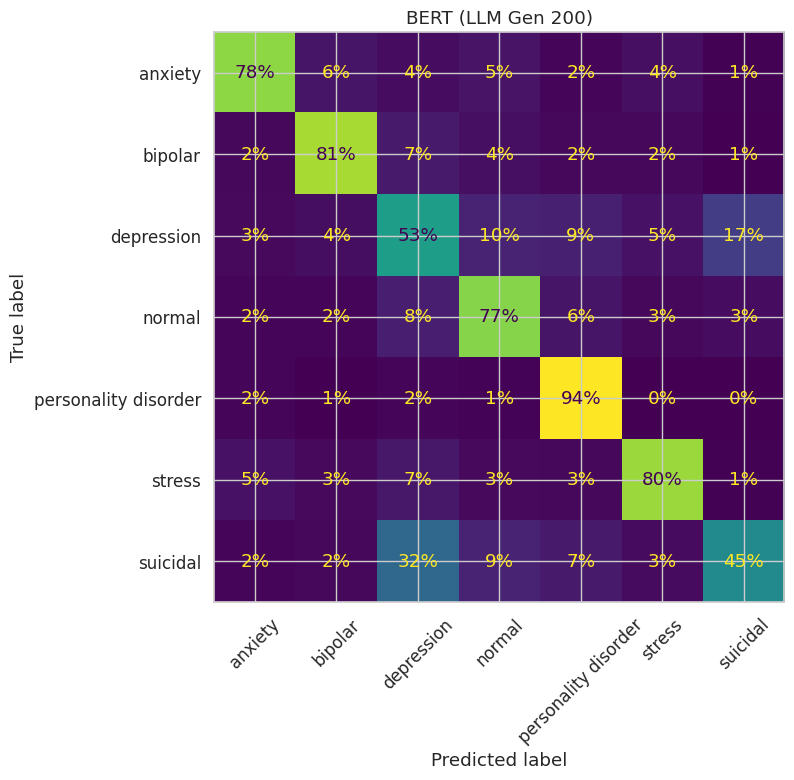

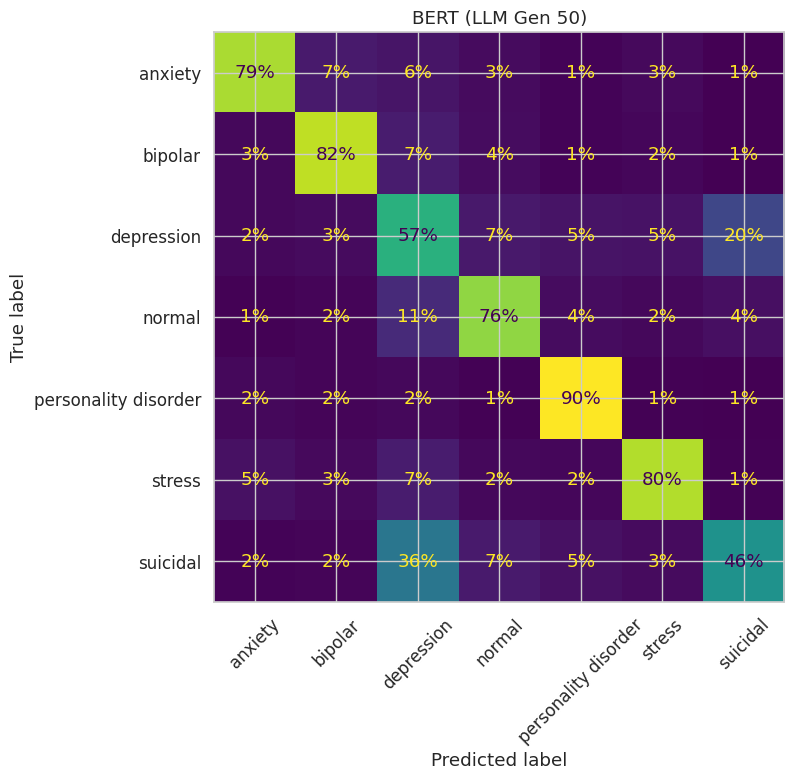

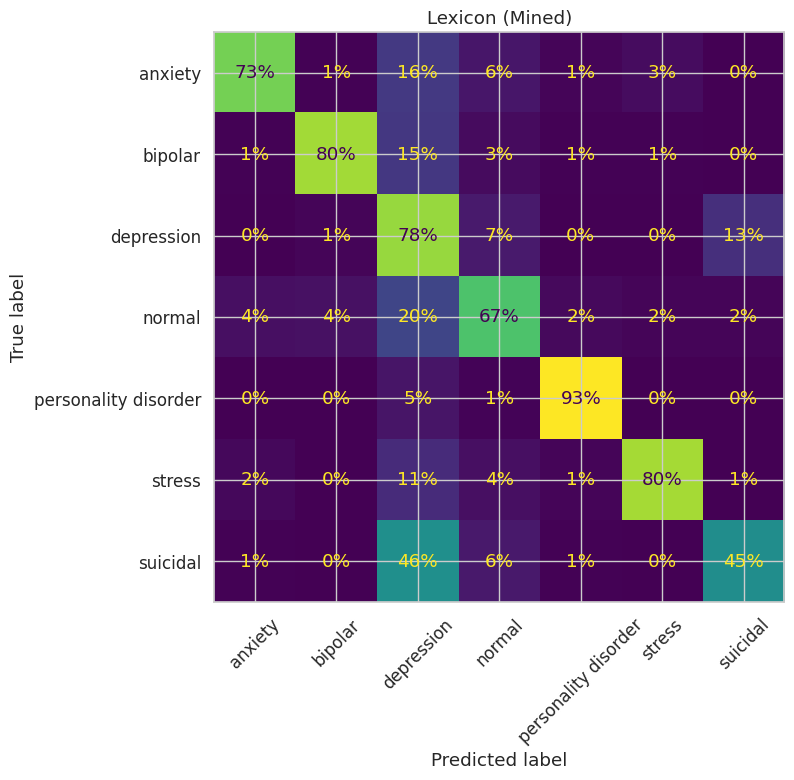

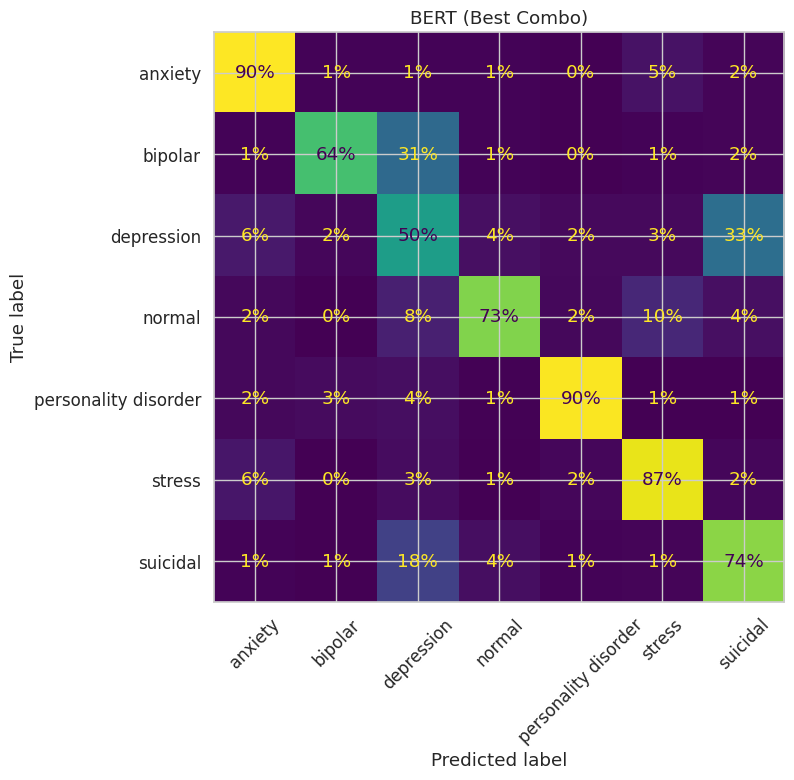

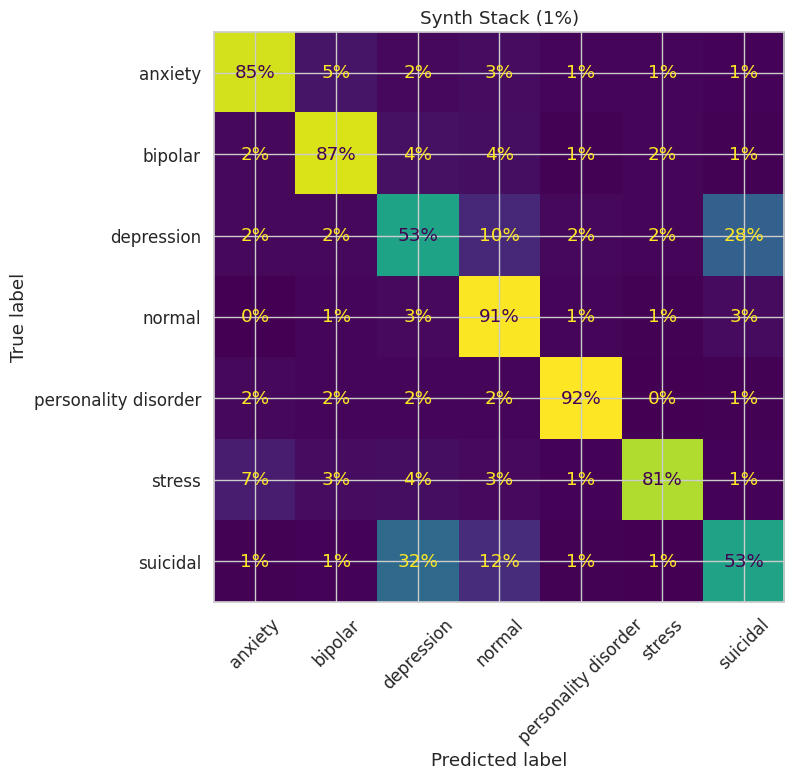

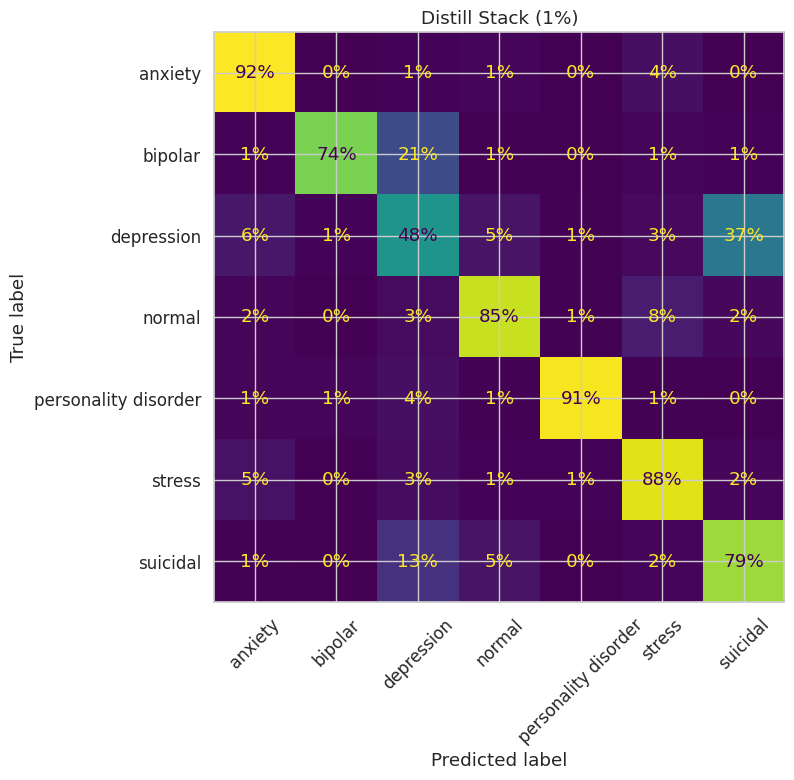

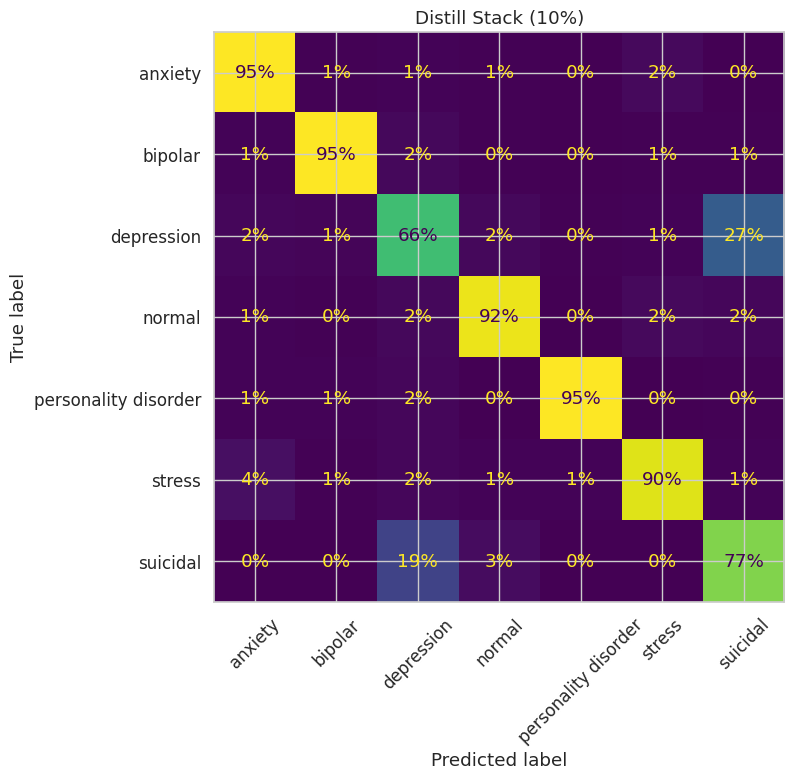

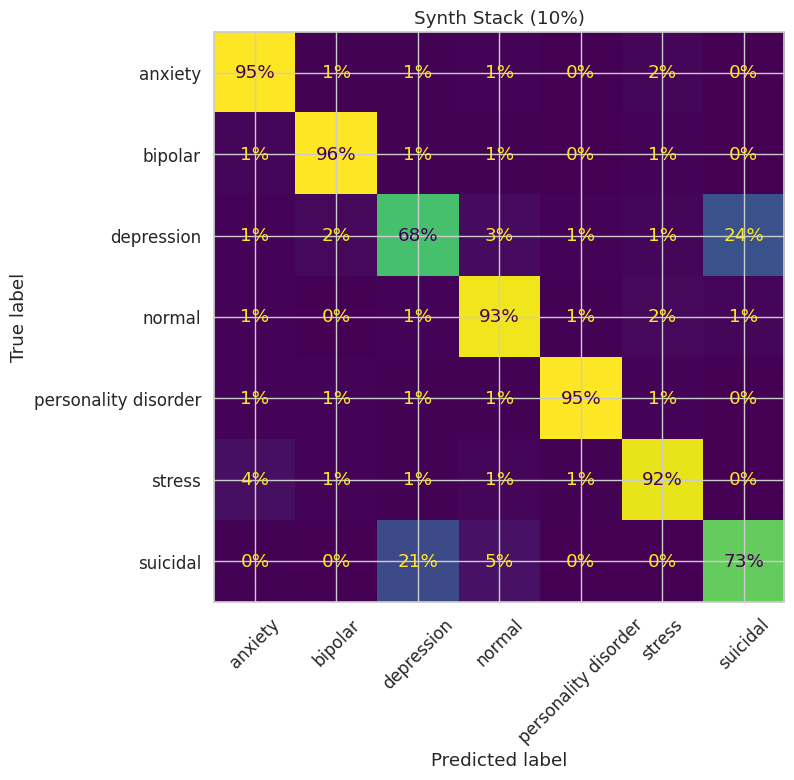

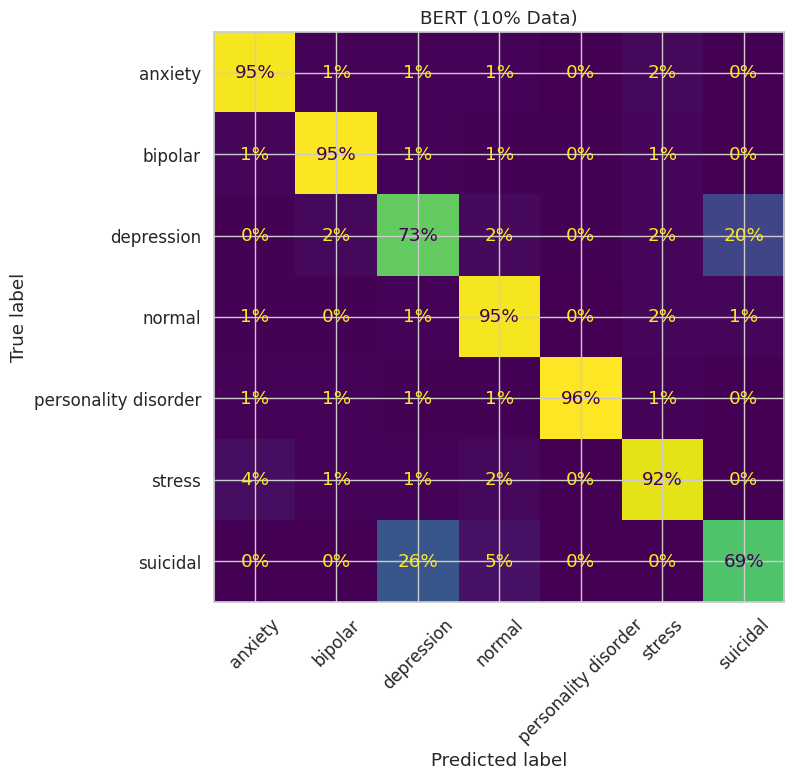

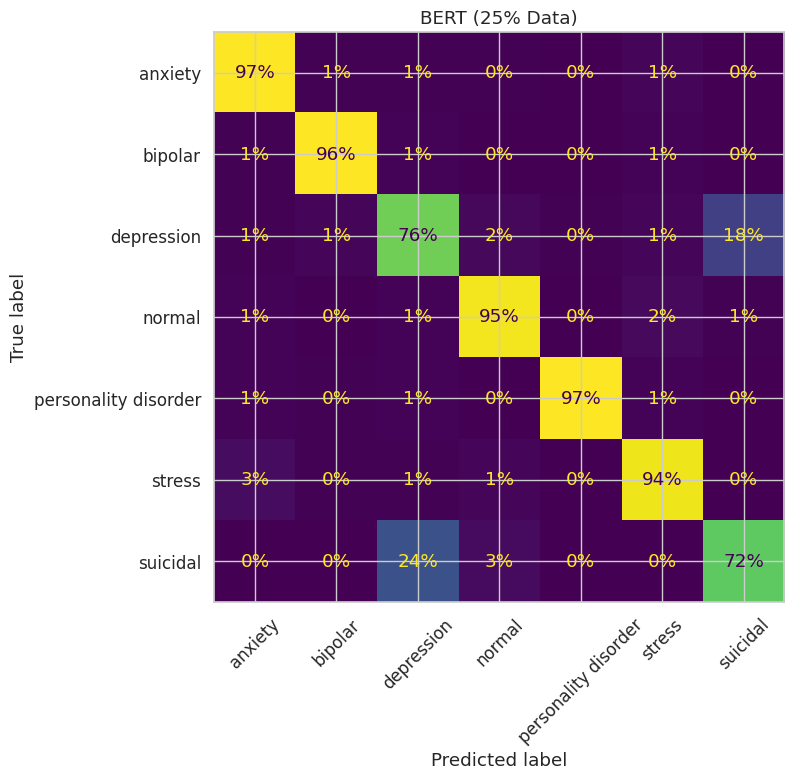

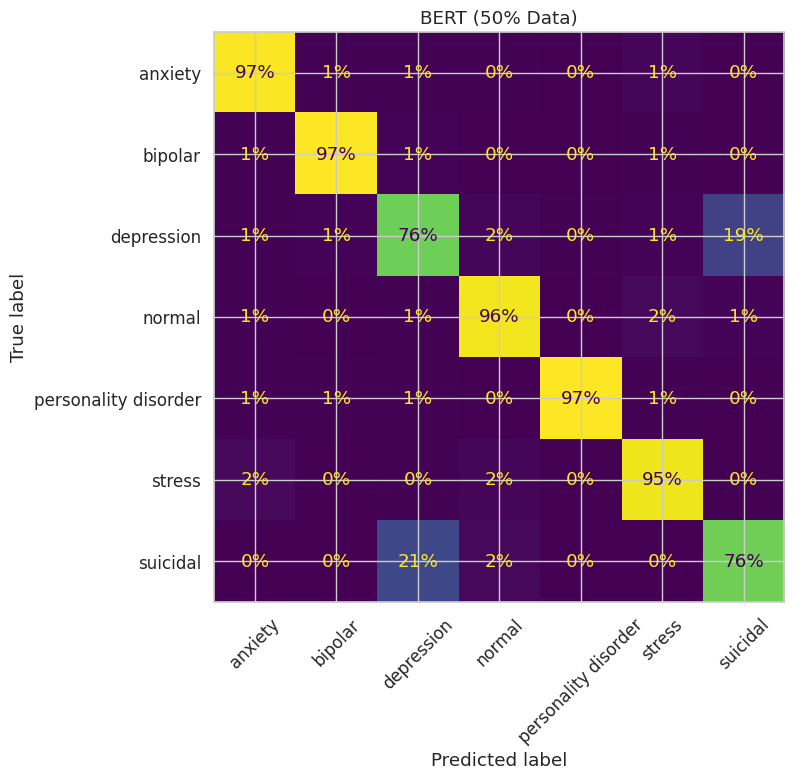

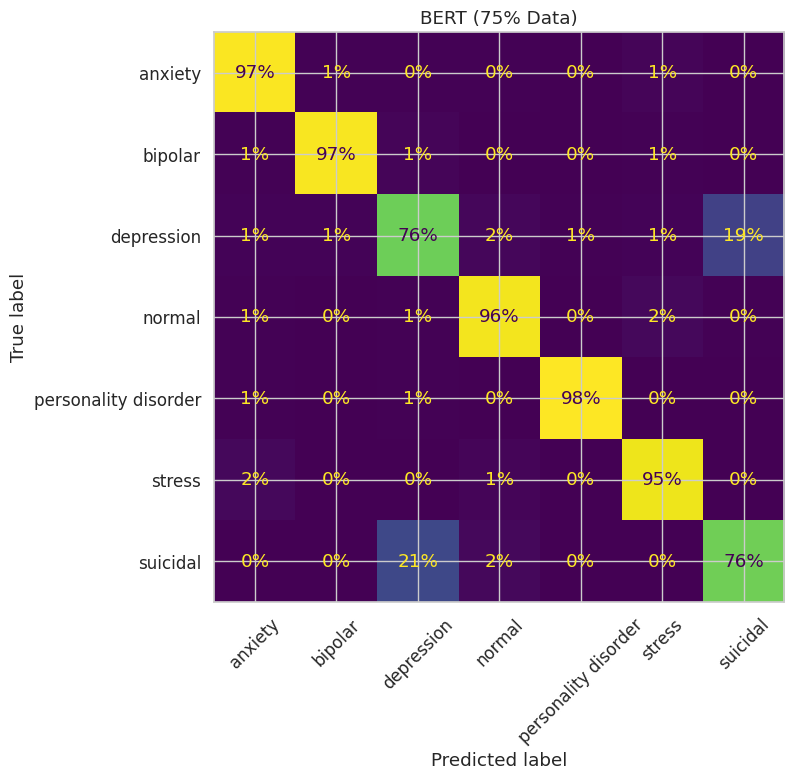

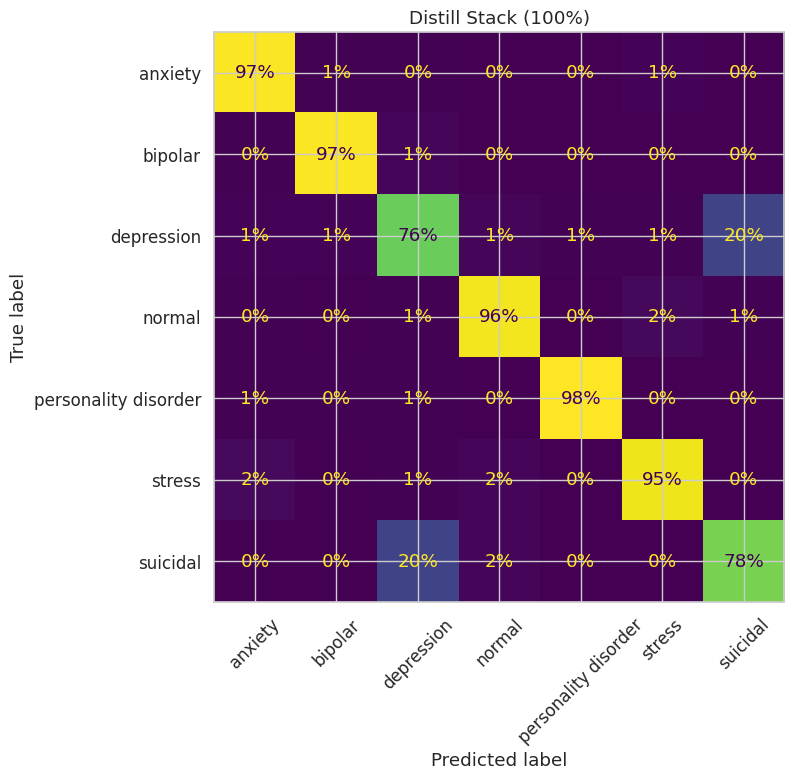

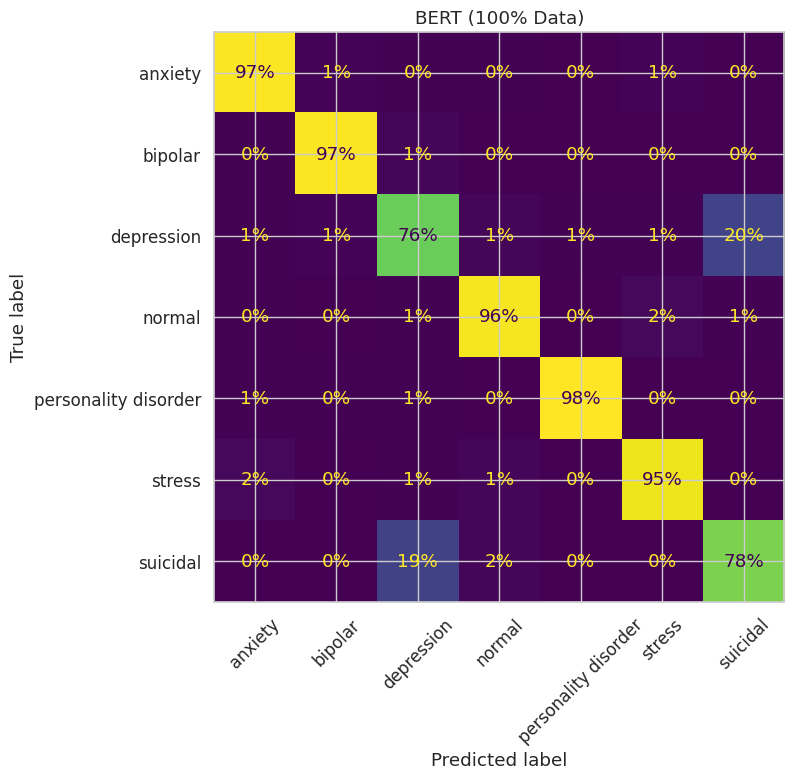

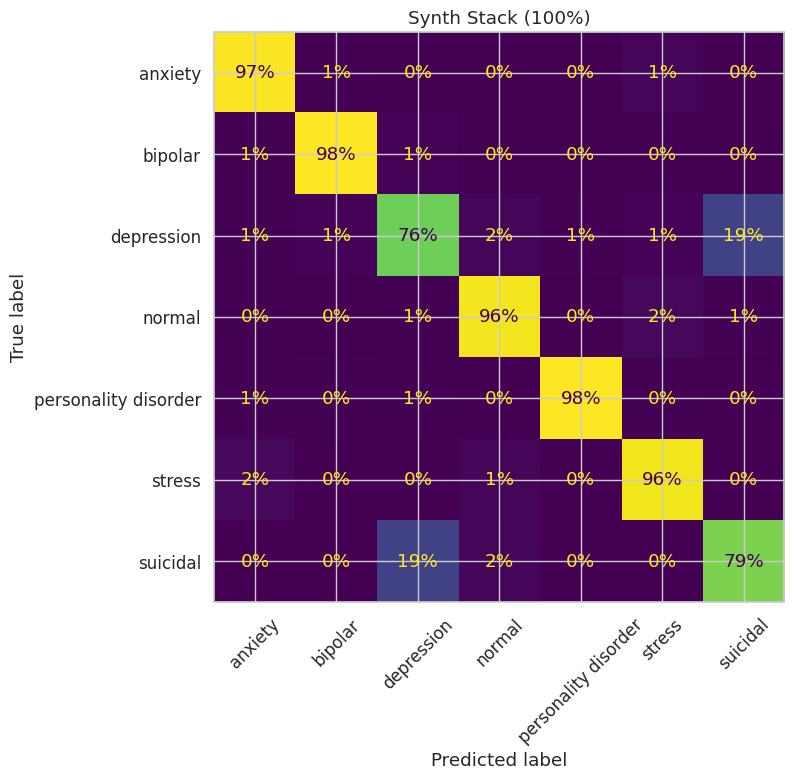

No saved predictions for part0_soa_reference - skipped.


In [13]:
for name in ladder['experiment']:
    plot_confusion_from_predictions(name, classes, save_fig=save_fig, title=format_model_name(name))


### 4.2 Per-Class Recall Heatmap

Overall accuracy can hide failures on individual classes, so this heatmap shows recall per true class (the share of posts in a class the model identifies), with models as rows and classes as columns; green is high recall, red is low. It surfaces a model's weak spots quickly. In Part 1, for example, changing the lexicon moved the misclassifications from normal to depression rather than fixing them, which is why improvements must target specific classes, especially suicidal.

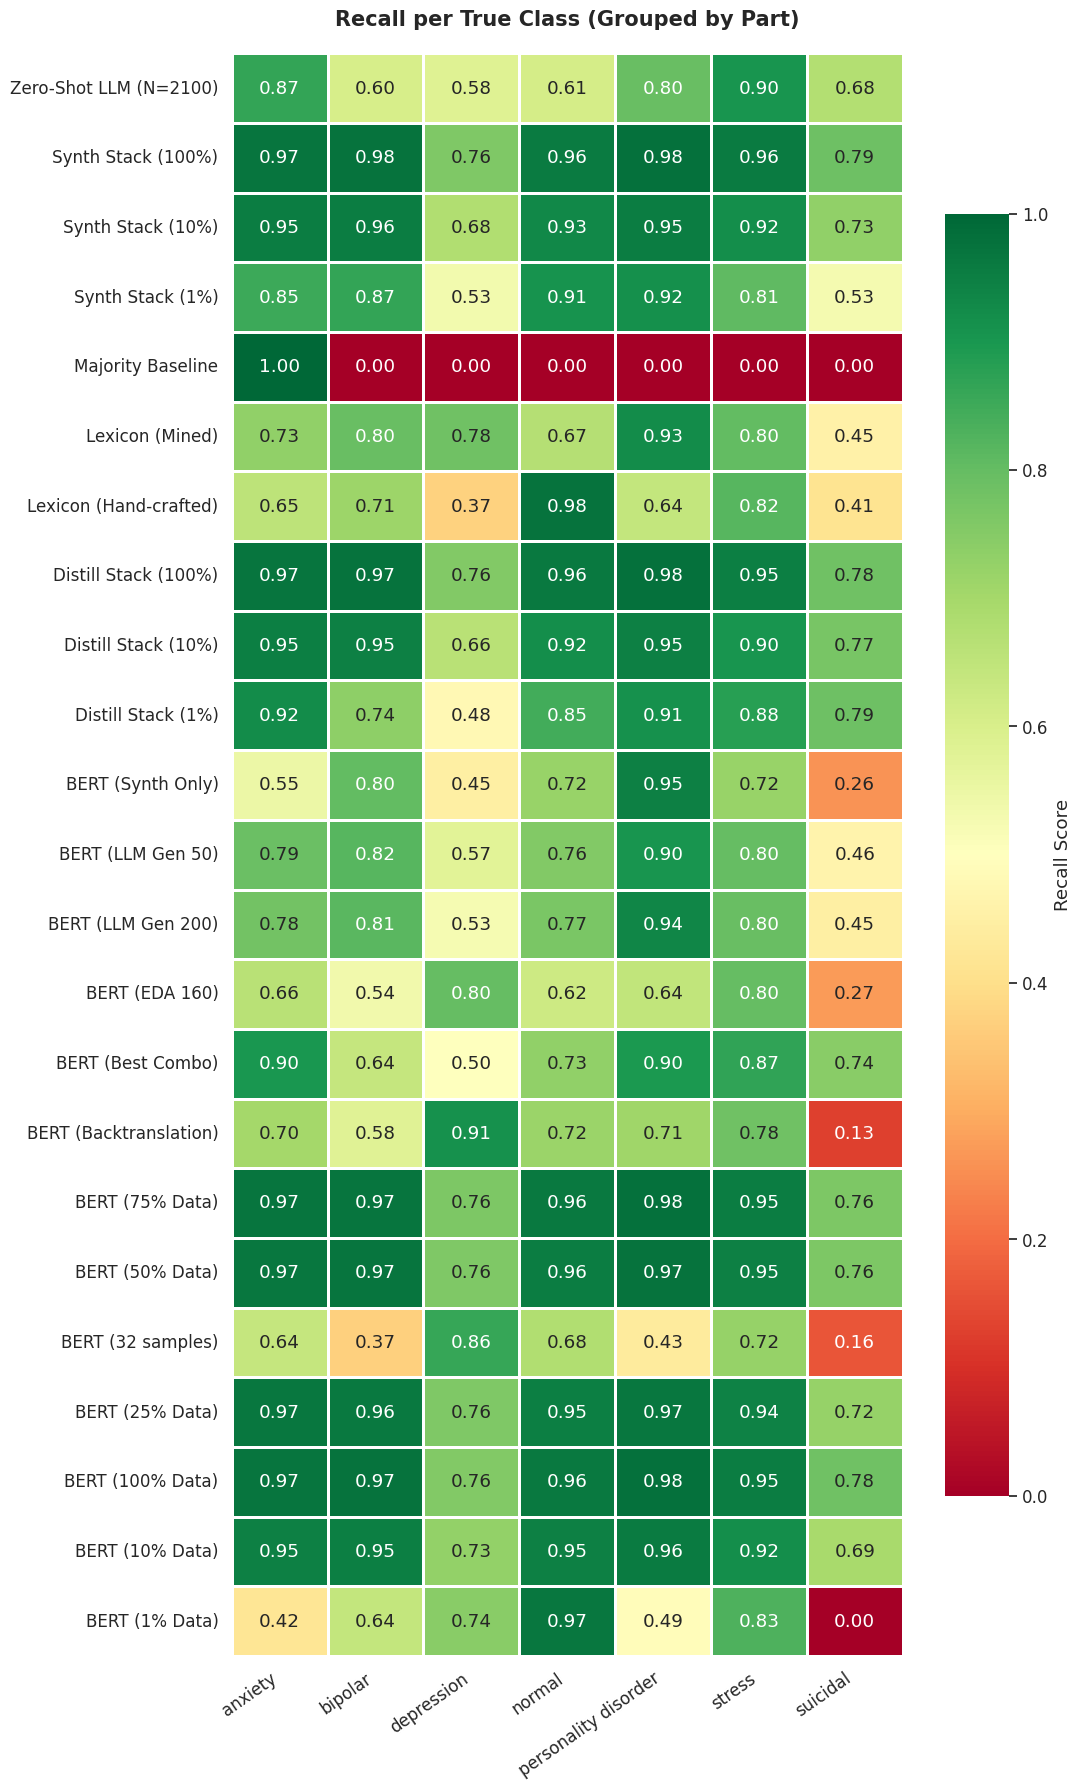

In [45]:
plot_recall_heatmap(load_all_metrics, classes, y_test, save_fig=save_fig, format_model_name=format_model_name)

### 4.3 Suicidal Recall (Ethics-Critical Metric)

In a screening or triage framing the costly error is the false negative: a suicidal text filed under `depression` or `normal` is an at-risk person the system fails to flag. So the suicidal class gets its recall tracked separately for every model, all the way to the final distilled model in Part 4. A model that wins on accuracy but drops suicidal recall is not an upgrade in this domain; that trade-off must stay visible, not buried in a macro average.

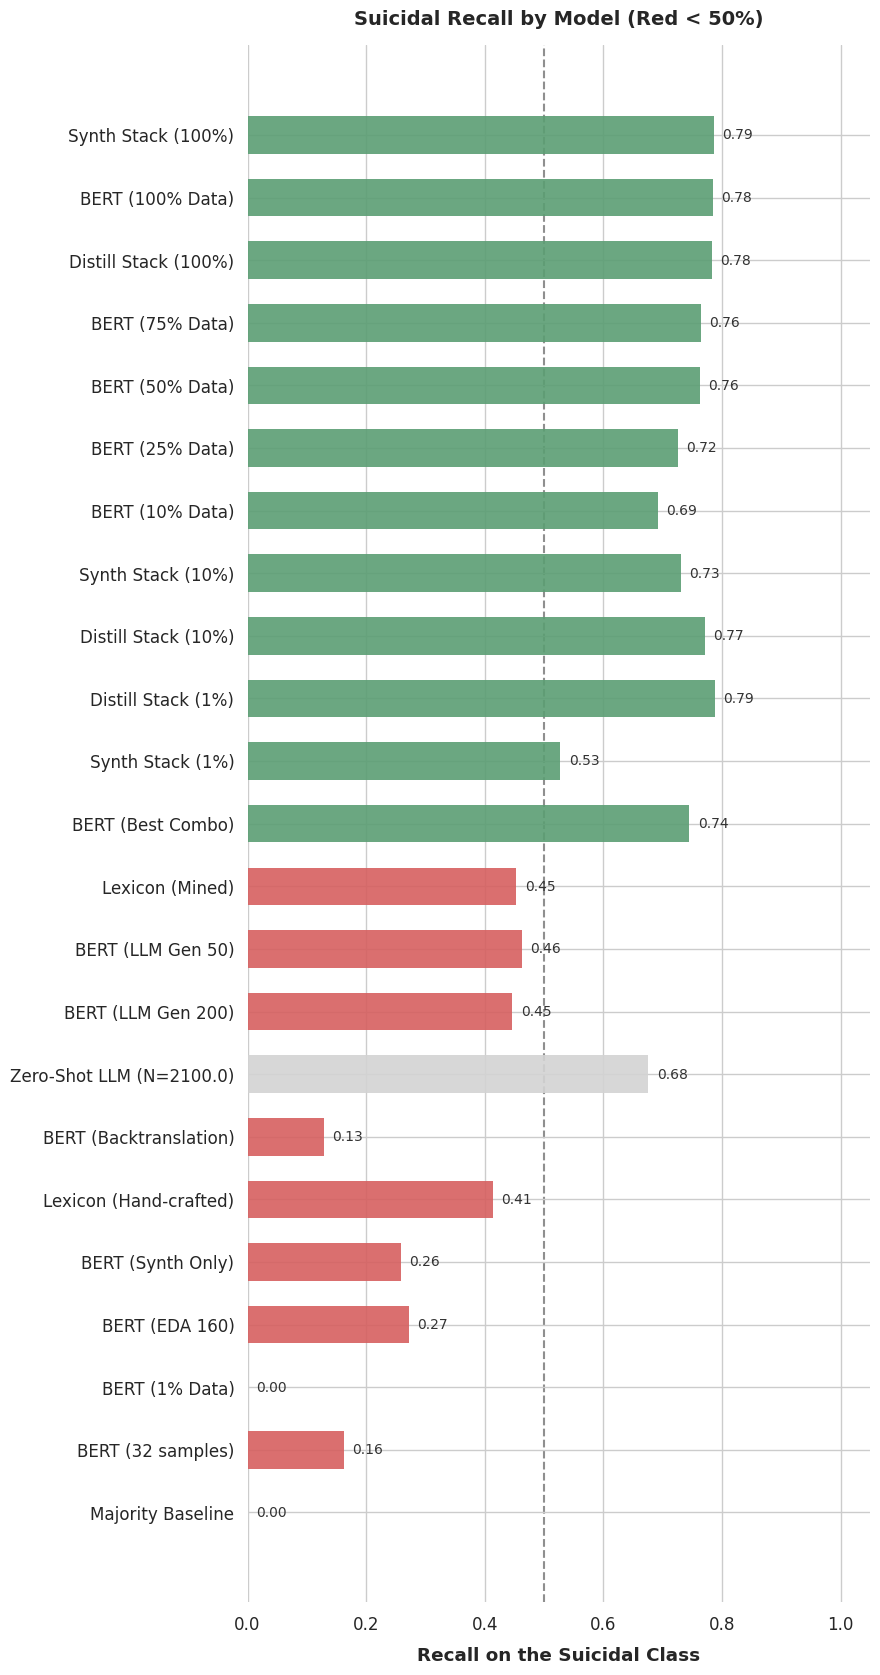

In [14]:
plot_suicidal_recall(ladder, y_test, save_fig=save_fig, format_model_name=format_model_name)


### 4.4 Suicidal False Negatives

The actual texts the best model labelled as something else, usually `depression`, when they were truly suicidal. These are the **false negatives** behind the suicidal-recall number: recall tells us how many we miss, and reading the posts tells us why, which is the first step toward fixing it.

In [ ]:
model_to_analyze = 'part3_bert_pct100'
pred_df = load_predictions(model_to_analyze)

analysis_df = test_df.copy()
analysis_df['y_pred'] = pred_df['y_pred'].values
analysis_df['y_true'] = pred_df['y_true'].values

fn_mask = (analysis_df['y_true'] == 'suicidal') & (analysis_df['y_pred'] != 'suicidal')
suicidal_misses = analysis_df[fn_mask]

print(f"Total 'suicidal' texts missed by {model_to_analyze}: {len(suicidal_misses)}")
print("\n--- Breakdown of Misclassifications ---")
display(suicidal_misses['y_pred'].value_counts().to_frame('Predicted As'))

print("\n--- Examples of Suicidal texts misclassified as 'depression' ---")
dep_misses = suicidal_misses[suicidal_misses['y_pred'] == 'depression']

for i, row in enumerate(dep_misses.head(3).itertuples()):
    print(f"\n[{i+1}] True: suicidal | Predicted: depression")
    # Print first 400 characters to keep output manageable
    print(f"Text: {row.text[:400]}...")


ERROR_ANALYSIS_DIR = RESULTS_DIR / 'error_analysis'
ERROR_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

save_path = ERROR_ANALYSIS_DIR / f'suicidal_misses_{model_to_analyze}.csv'

suicidal_misses.to_csv(save_path, index=False)

print(f"Successfully saved {len(suicidal_misses)} misclassified examples to:")
print(save_path)

Total 'suicidal' texts missed by part3_bert_pct100: 457

--- Breakdown of Misclassifications ---


,Predicted As
y_pred,
depression,412
normal,35
stress,4
bipolar,3
anxiety,2
personality disorder,1



--- Examples of Suicidal texts misclassified as 'depression' ---

[1] True: suicidal | Predicted: depression
Text: i do not want to be alone anymore i fucking cannot take it. i am losing my mind seeing everyone love each other day and night and i have to cry alone forever. i am always going to be alone. why tho? why could not it have been me to have a nice life why could not i bee good looking or smart fuckin shit fuck fuck fuck help please....

[2] True: suicidal | Predicted: depression
Text: they think they can "snoop" at me without me noticing. i notice it and they are wrong for thinking i do not notice it and for thinking negatively of me. i take my time speaking because i want to be vulnerable with my problems to them hoping they would understand, instead they misinterpret it with me being dumb. when i first started opening up, my father called me "crazy". now, they think i am "dum...

[3] True: suicidal | Predicted: depression
Text: so i am drunk, i have no one to vent to, and i

## 5. Overall Results Ladder

The ladder is built from every validated metrics JSON on disk, one row per experiment. Accuracy with its 95% confidence interval is the primary metric, and the interval reflects sampling uncertainty on this test set. Macro F1 averages F1 equally across the seven classes, so a model cannot score well by handling only common classes. Cohen's kappa corrects agreement for chance (0 is chance, 1 is perfect). Suicidal recall is the ethics-critical metric, since a missed suicidal post is the costly error. The random baseline stores a simulation summary, so its kappa and per-class cells are blank.

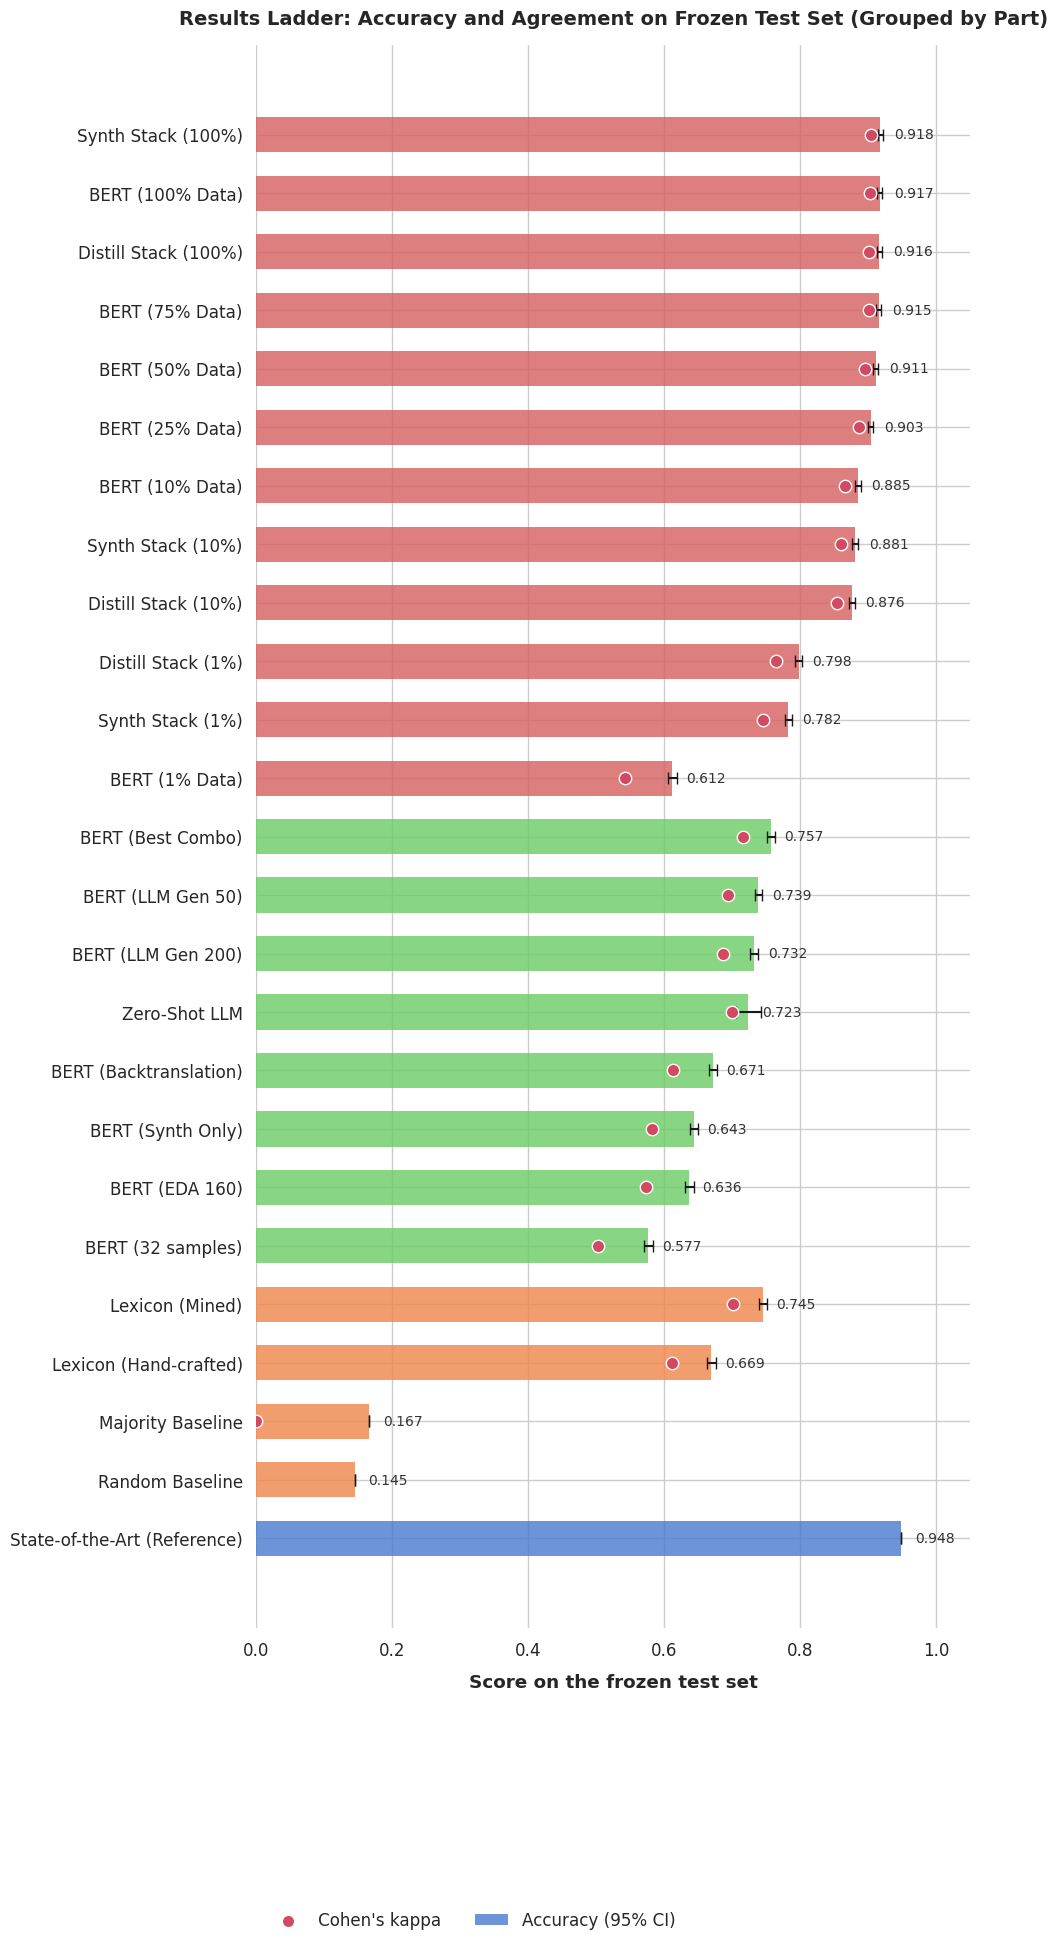

In [ ]:
plot_results_ladder(ladder, save_fig=save_fig, format_model_name=format_model_name)

### 5.1 Macro F1 vs Suicidal Recall

This scatter plots each model's macro F1 (x-axis, overall balanced performance across the seven classes) against its suicidal recall (y-axis, the share of suicidal posts correctly flagged). A model can reach a high macro F1 on common classes while still missing suicidal cases; the plot shows whether general performance comes at that cost.

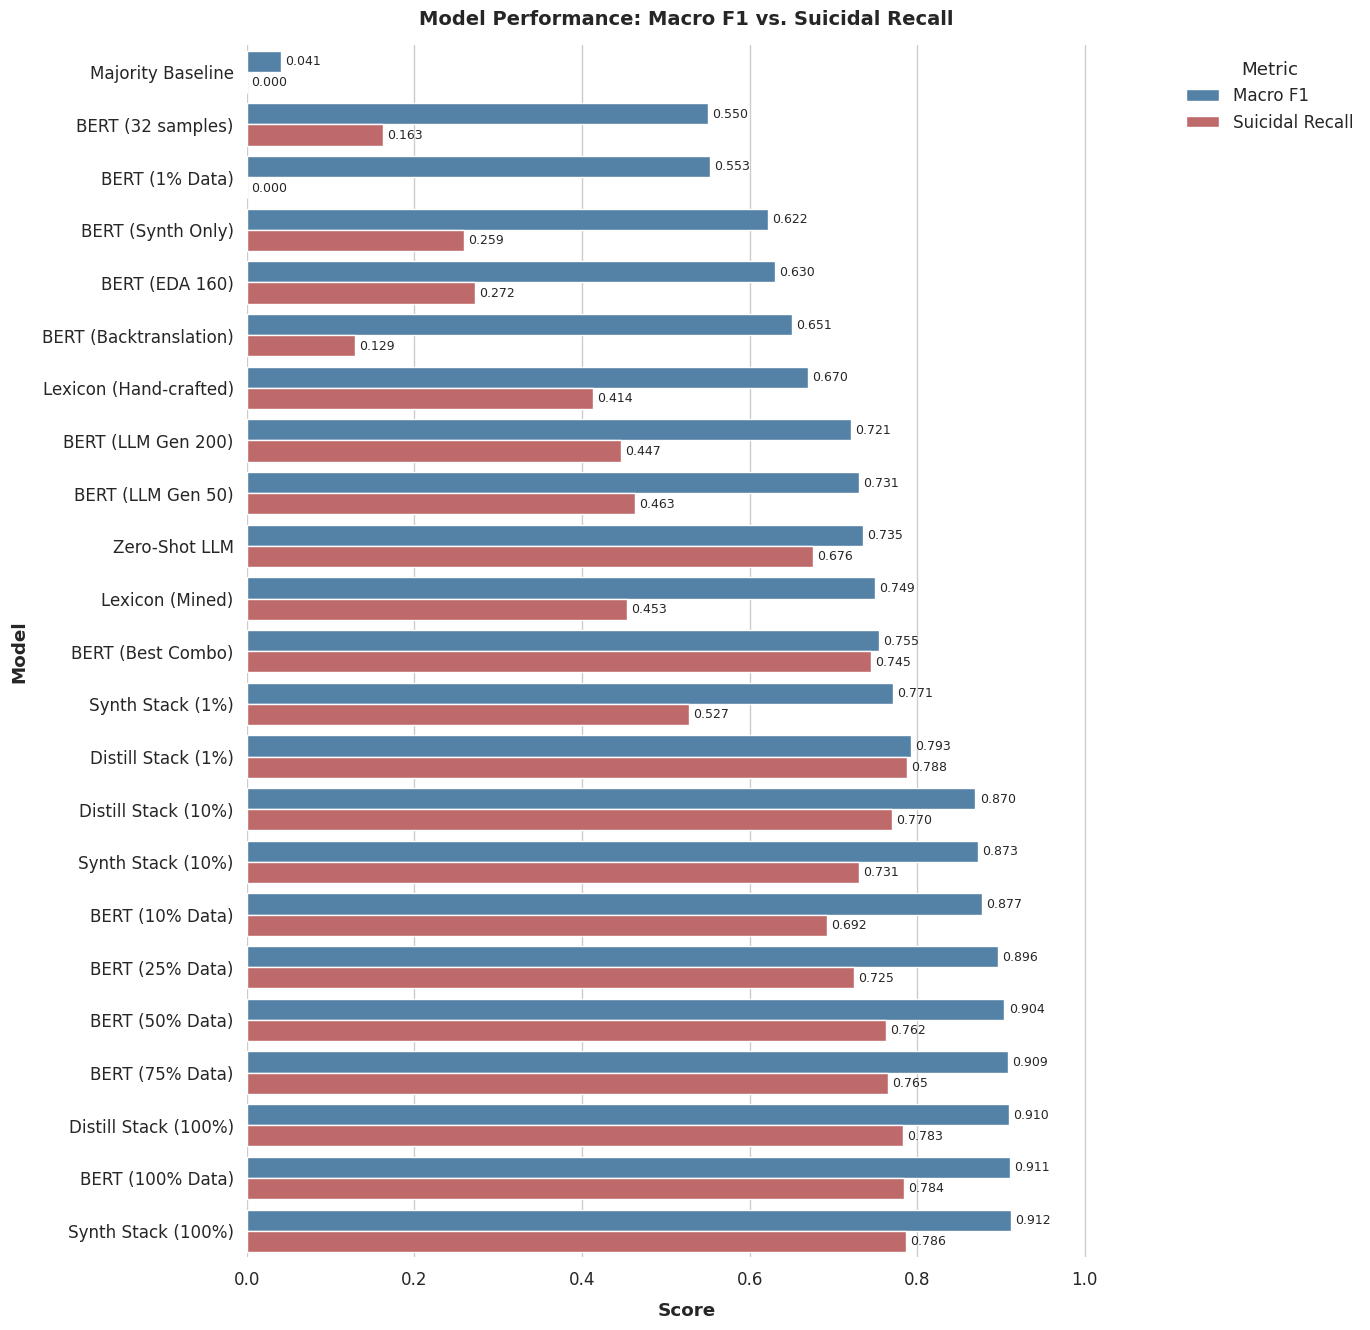

In [ ]:
plot_f1_vs_recall(ladder, save_fig=save_fig, format_model_name=format_model_name)

### 5.2 Top 3 Models vs. SOA

This section compares our three best-performing models against a published **State-of-the-Art (SOA)** benchmark. The goal is to see how close our models get to the current best performance, and whether they achieve it without compromising on the ethically critical metric of suicidal recall.

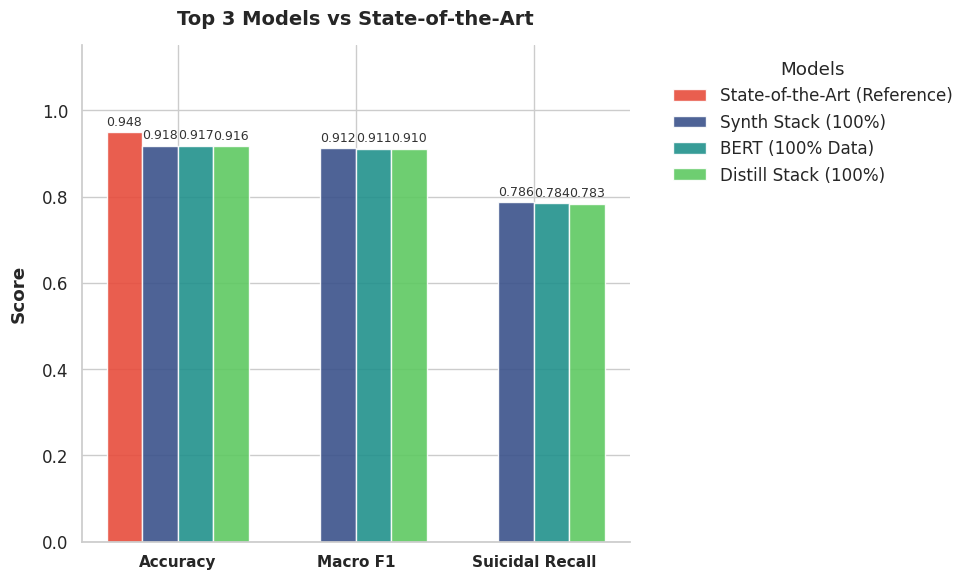

In [ ]:
plot_top3_vs_soa(ladder, save_fig=save_fig, format_model_name=format_model_name)

## 6. Statistical Significance (Paired Tests)

Two models scored on the same test set are paired samples, so checking whether their bootstrap CIs overlap is not a valid difference test. McNemar's test looks only at the texts where the two models disagree (one right, the other wrong) and asks whether those wins split 50/50; a small p-value means the models genuinely differ.

This needs per-example predictions, which `evaluate_model()` persists to `results/predictions/{name}.csv`; the cell below runs McNemar for every pair found there. The Part 1 baselines were compared inline in notebook 01, before this convention existed (hand-crafted vs mined: mined-only correct on 4,224 texts vs 2,701, p = 2.54e-75, so the mined lexicon wins decisively); their prediction CSVs will be backfilled via `save_predictions()` only, after an accuracy-equality assert against the persisted JSONs (see `docs/PART2_PLAN.md` section 2 gap #2), and the Part 1 metrics JSONs are never rewritten.

In [ ]:
# Pairwise McNemar across all persisted prediction files. Each file must align with the
# frozen test set (same test_id index, same ground truth) - a misaligned or stale file is
# reported and skipped, so one bad file can't poison or abort the other comparisons.
pred_files = sorted(PRED_DIR.glob('*.csv')) if PRED_DIR.exists() else []
valid = {}
for p in pred_files:
    frame = load_predictions(p.stem)
    if not frame.index.equals(test_df.index):
        print(f"SKIPPED {p.name}: test_id index does not match the frozen test set.")
    elif not (frame['y_true'].to_numpy() == y_test).all():
        print(f"SKIPPED {p.name}: stored y_true disagrees with the frozen test labels (stale file?).")
    else:
        valid[p.stem] = frame

if len(valid) < 2:
    print(f"{len(valid)} usable prediction file(s) in results/predictions/ - McNemar needs at least 2.")
    print("Every evaluate_model() call adds one; re-run this cell once Parts 2-4 land.")
else:
    pairs = [{'model_a': a, 'model_b': b,
              **mcnemar_test(y_test, valid[a]['y_pred'], valid[b]['y_pred'])}
             for a, b in itertools.combinations(valid, 2)]
    mcnemar_table = pd.DataFrame(pairs).sort_values('p_value').reset_index(drop=True)

    display_table = mcnemar_table.copy()
    display_table['model_a'] = display_table['model_a'].apply(lambda x: format_model_name(x))
    display_table['model_b'] = display_table['model_b'].apply(lambda x: format_model_name(x))
    print(display_table.to_string(index=False))
    print('\nSmall p-value -> the two models genuinely differ on this test set.')

               model_a                model_b  a_only_correct  b_only_correct       p_value
       Lexicon (Mined)      BERT (32 samples)            4791            1421  0.000000e+00
       Lexicon (Mined)   Distill Stack (100%)             572            3993  0.000000e+00
       Lexicon (Mined)    Distill Stack (10%)             915            3529  0.000000e+00
       Lexicon (Mined)        BERT (75% Data)             557            3967  0.000000e+00
       Lexicon (Mined)        BERT (50% Data)             573            3890  0.000000e+00
       Lexicon (Mined)        BERT (25% Data)             572            3740  0.000000e+00
       Lexicon (Mined)       BERT (100% Data)             572            4018  0.000000e+00
       Lexicon (Mined)        BERT (10% Data)             722            3518  0.000000e+00
     BERT (32 samples)      BERT (Best Combo)            1993            5601  0.000000e+00
     BERT (32 samples)        BERT (10% Data)             737            6903  0